# Project Pt. 3: NBA Salaries Aren’t About Efficiency: The Roles of Age, Experience, and Scoring Variability (1950–2023)

## Team Members
- Ashley Kang (ashleykg)
- Min-Yi Chen (minyi)
- Chloe Yueh (yyueh)

## 0. Import packages

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


## 1. Preprocessing Data

### 1.1 Data Import and Initial Cleaning
In this section, we import the merged dataset and prepare it for machine learning. Our cleaning process involves:
1. Dropping irrelevant identification columns (e.g., player names).
2. Identifying and handling missing values.
3. Removing duplicate rows.
4. Addressing data inconsistencies (e.g., ensuring percentages are within valid ranges).
5. Creating a derived feature (`PTS_per_game`) to better represent a player's scoring impact regardless of the total games played.

In [50]:
import os

# Validate that the file produced by Part 1 exists before loading
assert os.path.exists("merged_data.csv"), (
    "merged_data.csv not found. Run Part 1 notebook first to generate it."
)

# Import the dataset
df = pd.read_csv('merged_data.csv')
print("=" * 60)
print(f"Original dataset shape : {df.shape}")
print("=" * 60)
# print(df.head(3))

# Drop irrelevant columns (player names are not useful for ML prediction)
columns_to_drop = ['player']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Handle missing values
# check how many missing values exist
missing_count = df_cleaned.isnull().sum().sum()
print("\n[Missing Values]")
print(f"Total missing values   : {missing_count}")
if missing_count == 0:
    print("No missing values found. No imputation needed.")
else:
    print(f"Found {missing_count} missing values. Handling required.")
    df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))
# Since missing count is 0, no dropna() or imputation is needed!

duplicate_count = df_cleaned.duplicated().sum()
print("\n[Duplicate Rows]")
print(f"Total duplicate rows   : {duplicate_count}")

if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates().copy()
    print(f"Shape after removing duplicates: {df_cleaned.shape}\n")
else:
    print("No duplicate rows found.\n")

# Handle inconsistencies
# Ensure percentages (like FG%) are between 0 and 1 and games played (G) is greater than 0.
# This prevents extreme outliers or data entry errors from skewing the model
df_cleaned = df_cleaned[
    df_cleaned['FG%'].between(0, 1)
    & df_cleaned['FT%'].between(0, 1)
    & (df_cleaned['G'] > 0)
].copy()

# Feature engineering: create 'PTS_per_game'
# Total points can be misleading if a player played very few games. 
# Points per game is a more standardized metric for evaluating performance.
if 'PTS' in df_cleaned.columns and 'G' in df_cleaned.columns:
    df_cleaned['PTS_per_game'] = df_cleaned['PTS'] / df_cleaned['G']

print('\n' + '=' * 60)
print('Cleaning Summary')
print(f"Final dataset shape    : {df_cleaned.shape}")
print('=' * 60)
print('\nCheck data types and non-null counts after cleaning:')
df_cleaned.info()
print()
df_cleaned.head()

Original dataset shape : (13604, 17)

[Missing Values]
Total missing values   : 0
No missing values found. No imputation needed.

[Duplicate Rows]
Total duplicate rows   : 518
Shape after removing duplicates: (13086, 16)


Cleaning Summary
Final dataset shape    : (13086, 17)

Check data types and non-null counts after cleaning:
<class 'pandas.DataFrame'>
Index: 13086 entries, 0 to 13602
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   season              13086 non-null  int64  
 1   Pos                 13086 non-null  str    
 2   Age                 13086 non-null  float64
 3   Tm                  13086 non-null  str    
 4   G                   13086 non-null  float64
 5   GS                  13086 non-null  float64
 6   MP                  13086 non-null  float64
 7   FG                  13086 non-null  float64
 8   FGA                 13086 non-null  float64
 9   FG%                 13086 non-nu

,season,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,FT,FTA,FT%,PTS,salary,inflationAdjSalary,PTS_per_game
0,1990,C,27.0,ORL,80.0,50.0,1691.0,138.0,285.0,0.484211,83.0,120.0,0.691667,362.0,437000.0,996827.0,4.525000
1,1990,PG,27.0,DEN,79.0,74.0,2690.0,398.0,989.0,0.402427,267.0,314.0,0.850318,1221.0,825000.0,1881882.0,15.455696
2,1990,SF,30.0,DET,78.0,40.0,2005.0,438.0,898.0,0.487751,192.0,254.0,0.755906,1099.0,1115000.0,2543393.0,14.089744
3,1990,PG,30.0,SAC,75.0,68.0,2727.0,506.0,1154.0,0.438475,222.0,267.0,0.831461,1342.0,725000.0,1653775.0,17.893333
4,1990,PF,26.0,WSB,82.0,10.0,1893.0,371.0,785.0,0.472611,108.0,133.0,0.812030,860.0,500000.0,1140535.0,10.487805


The initial cleaning process successfully streamlined our dataset. By dropping the `player` column, we removed a non-predictive identifier that would not be meaningful for machine learning. Our missing value check confirmed 0 missing entries. In the current merged dataset, no columns contained missing values, so no imputation or row removal was necessary at this stage. However, we identified and removed 518 duplicate rows to prevent the model from overfitting to repeated observations.

Next, we addressed basic data consistency by ensuring that percentage-based variables such as `FG%` remained within the valid range of 0 to 1. This step helps protect the model from impossible values caused by data-entry errors or data-merging issues. Finally, we engineered a new feature, `PTS_per_game`, to better represent scoring productivity on a per-game basis. This derived variable is more informative than raw total points alone because it accounts for differences in the number of games played.

### 1.2 Encoding, Splitting & Scaling

To prepare our data for classification, we must strictly avoid data leakage. Therefore, we perform the train-test split *before* any scaling or encoding. Our process includes:
1. **Target Definition:** We convert the continuous `inflationAdjSalary` into a categorical target (`Salary_Tier`) with three balanced classes: Low, Mid, and High, using quantile-based discretization (`pd.qcut`).
2. **Train-Test Split:** We set aside 20% of our data for testing to evaluate our models on unseen data later.
3. **ColumnTransformer Pipeline:** Following best practices from class, we use `sklearn.compose.ColumnTransformer` to apply `StandardScaler` to all numerical features (preventing magnitude bias) and `OneHotEncoder` to categorical features (`Pos`, `Tm`). This ensures transformations are fitted solely on the training data.

In [51]:
# Define Target Label: Split salary into 3 equal-sized tiers (Low, Mid, High)
salary_bins = pd.qcut(df_cleaned['inflationAdjSalary'], q=3, retbins=True)
thresholds = salary_bins[1]  # array of bin edges
df_cleaned['Salary_Tier'] = pd.qcut(df_cleaned['inflationAdjSalary'], q=3, labels=['Low', 'Mid', 'High'])
print(f"Salary_Tier thresholds (inflation-adjusted):")
print(f"  Low  : up to         ${thresholds[1]:,.0f}")
print(f"  Mid  : ${thresholds[1]:,.0f} – ${thresholds[2]:,.0f}")
print(f"  High : above         ${thresholds[2]:,.0f}")

# Define Features (X) and Target (y)
# Drop the target columns and any raw salary columns to prevent the model from cheating
# We also exclude season so that the model focuses on player-level attributes and performance rather than learning era-specific salary patterns.
X = df_cleaned.drop(columns=['salary', 'inflationAdjSalary', 'Salary_Tier', 'season'])
y = df_cleaned['Salary_Tier']

# Check class balance before splitting
print("Class distribution in full dataset:")
print(y.value_counts())
print("\nClass proportions in full dataset:")
print((y.value_counts(normalize=True)).round(3))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows\n")

print("Training set class proportions:")
print((y_train.value_counts(normalize=True)).round(3))

print("\nTesting set class proportions:")
print((y_test.value_counts(normalize=True)).round(3))

# Separate column names by type
numeric_features = ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'FT', 'FTA', 'FT%', 'PTS', 'PTS_per_game']
categorical_features = ['Pos', 'Tm']

# Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Fit and Transform on Training set
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nFeatures before encoding: {X_train.shape[1]}")
print(f"Features after ColumnTransformer (Scaling + One-Hot): {X_train_processed.shape[1]}")

feature_names = preprocessor.get_feature_names_out()
# Convert the processed training features back to a DataFrame for better visualization
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

print("\nDataFrame after ColumnTransformer processing (first 3 rows):")
X_train_df.head(3)

Class distribution in full dataset:
Salary_Tier
Low     4362
Mid     4362
High    4362
Name: count, dtype: int64

Class proportions in full dataset:
Salary_Tier
Low     0.333
Mid     0.333
High    0.333
Name: proportion, dtype: float64

Training set size: 10468 rows
Testing set size: 2618 rows

Training set class proportions:
Salary_Tier
High    0.333
Low     0.333
Mid     0.333
Name: proportion, dtype: float64

Testing set class proportions:
Salary_Tier
Low     0.333
Mid     0.333
High    0.333
Name: proportion, dtype: float64

Features before encoding: 14
Features after ColumnTransformer (Scaling + One-Hot): 67

DataFrame after ColumnTransformer processing (first 3 rows):


,num__Age,num__G,num__GS,num__MP,num__FG,num__FGA,num__FG%,num__FT,num__FTA,num__FT%,...,cat__Tm_POR,cat__Tm_SAC,cat__Tm_SAS,cat__Tm_SEA,cat__Tm_TOR,cat__Tm_TOT,cat__Tm_UTA,cat__Tm_VAN,cat__Tm_WAS,cat__Tm_WSB
0,0.545691,-2.095541,-0.918118,-1.389845,-1.092193,-1.144331,1.653058,-0.825237,-0.864581,0.356744,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.670933,-0.533584,-0.952702,-0.920680,-0.843854,-0.842436,-0.292391,-0.638195,-0.710124,1.070426,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.670933,-0.027003,-0.814365,-0.493547,-0.653268,-0.627574,-0.324718,-0.507265,-0.563021,0.628361,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The dataset was successfully split into 10468 training samples and 2618 testing samples. Before splitting, we converted `inflationAdjSalary` into a categorical target variable, `Salary_Tier`, using quantile-based discretization. This created three nearly equal-sized classes: Low, Mid, and High, each representing about one-third of the dataset. By using `stratify=y` during the train-test split, we preserved this balanced class distribution in both the training and testing sets.

Next, we applied a `ColumnTransformer` to preprocess the features in a way that avoids data leakage. All numerical variables were standardized using `StandardScaler`, while the categorical variables `Pos` and `Tm` were transformed using `OneHotEncoder`. This process expanded the feature space from 14 original features to 67 processed features. This preprocessing step ensures that the dataset is both machine-readable and appropriately scaled for modeling.

### 1.3 Dimensionality Reduction

With 67 features after One-Hot Encoding, our dataset might suffer from the curse of dimensionality, introducing noise and increasing computation time. To address this, we apply Principal Component Analysis (PCA).

We will first fit a full PCA to visualize the Explained Variance Ratio (EVR) using a Scree Plot. Based on the cumulative variance, we will determine the optimal number of principal components to retain before transforming our train and test sets.

Explained variance ratio (first 10 components):
  PC1: 0.560
  PC2: 0.087
  PC3: 0.074
  PC4: 0.056
  PC5: 0.049
  PC6: 0.026
  PC7: 0.018
  PC8: 0.015
  PC9: 0.014
  PC10: 0.013


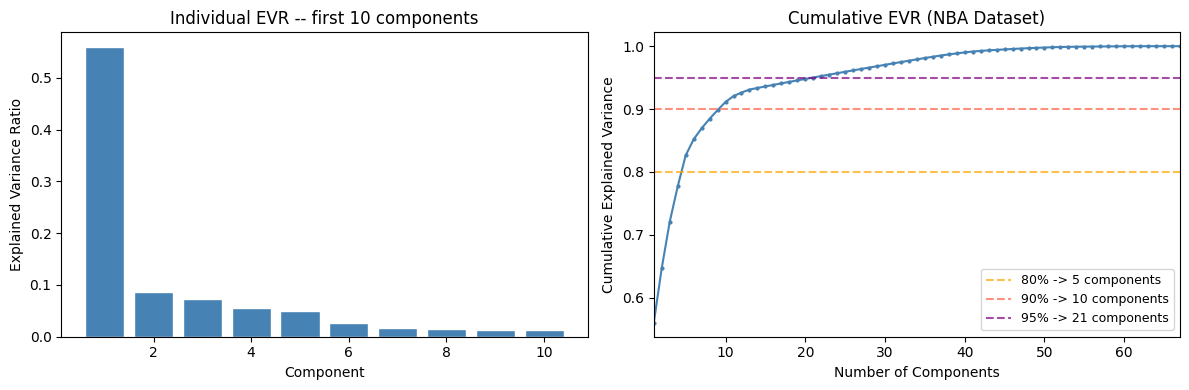

Components to reach 80%: 5
Components to reach 90%: 10
Components to reach 95%: 21

Final training set shape after PCA: (10468, 10)
Final testing set shape after PCA: (2618, 10)


In [52]:
# Fit PCA on the fully processed training set (all 67 components)
pca_full_nba = PCA(random_state=42)
pca_full_nba.fit(X_train_processed) # X_train_processed is already scaled from Step 1.2

print("Explained variance ratio (first 10 components):")
for i, evr in enumerate(pca_full_nba.explained_variance_ratio_[:10], 1):
    print(f"  PC{i}: {evr:.3f}")

# Scree plot
cumvar_nba = np.cumsum(pca_full_nba.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual EVR
axes[0].bar(range(1, 11), pca_full_nba.explained_variance_ratio_[:10],
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual EVR -- first 10 components')

# Cumulative EVR
axes[1].plot(range(1, len(cumvar_nba)+1), cumvar_nba, marker='.', ms=4, color='steelblue')
# Add horizontal lines for common variance thresholds
for threshold, color in [(0.80, 'orange'), (0.90, 'tomato'), (0.95, 'purple')]:
    n = np.argmax(cumvar_nba >= threshold) + 1
    axes[1].axhline(threshold, color=color, linestyle='--', alpha=0.7,
                    label=f'{threshold:.0%} -> {n} components')

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative EVR (NBA Dataset)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, 67) # We have 67 features in total

plt.tight_layout()
plt.show()

# Print the number of components needed for common thresholds
print(f"Components to reach 80%: {np.argmax(cumvar_nba >= 0.80)+1}")
print(f"Components to reach 90%: {np.argmax(cumvar_nba >= 0.90)+1}")
print(f"Components to reach 95%: {np.argmax(cumvar_nba >= 0.95)+1}")

# Final transformation: We choose to keep 90% of the variance
n_components_90 = np.argmax(cumvar_nba >= 0.90) + 1
pca_final = PCA(n_components=n_components_90, random_state=42)

# Fit & transform on Train, only Transform on Test
X_train_pca = pca_final.fit_transform(X_train_processed)
X_test_pca = pca_final.transform(X_test_processed)

print(f"\nFinal training set shape after PCA: {X_train_pca.shape}")
print(f"Final testing set shape after PCA: {X_test_pca.shape}")

Looking at the scree plot, it’s clear that keeping all 67 features is unnecessary. We noticed a sharp drop-off in explained variance after the first few components. Reaching 90% explained variance only takes 10 components, but pushing that to 95% would require 21 components.

**Why we chose the 90% threshold:**
We decided to cap the variance at 90% (keeping 10 components) because it offers the best trade-off between retaining useful information and reducing model complexity. If we went for 95%, we would have to more than double our feature count just to capture an extra 5% of variance. In the context of our NBA dataset, that final 5% likely reflects lower-importance variation, sparse team-specific dummy variables, or other highly specific patterns that may not meaningfully improve salary-tier prediction.

**How this helps modeling:**
By compressing our dataset down to these 10 core principal components, PCA reduced redundancy among features and transformed the data into orthogonal components, which helps simplify the feature space for downstream modeling. More importantly, reducing the dimensionality means the models we build next are less likely to focus on noisy or overly specific patterns in the training data. This should make the models more efficient and may also help reduce overfitting.


### 1.4 PCA Loadings and 2D Projection Visualization

Now that we have our principal components, we need to figure out what they actually mean. We can do this by looking at the feature loadings, which show which of our original NBA stats have the biggest influence on each new component. After that, we'll plot the first two components (PC1 and PC2) on a 2D scatter plot. This gives us a quick visual sanity check to see if the different salary tiers (Low, Mid, High) are naturally separating before we even start building our classification models.

--- Top 5 Positive Drivers for PC1 ---
num__PTS    0.356028
num__FG     0.353747
num__FGA    0.351589
num__MP     0.340984
num__FT     0.333929
Name: PC1, dtype: float64

--- Top 5 Positive Drivers for PC2 ---
num__FT%             0.673329
num__Age             0.322823
cat__Pos_PG          0.098058
num__PTS_per_game    0.089707
cat__Pos_SG          0.081519
Name: PC2, dtype: float64


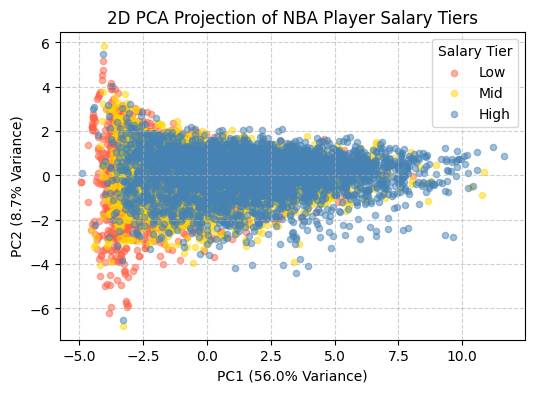

In [53]:
# Visualize PC1 & PC2 loadings (Identifying what the components represent)
# We use the feature names we extracted earlier
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=feature_names,
    columns=[f'PC{i}' for i in range(1, n_components_90 + 1)]
)

print("--- Top 5 Positive Drivers for PC1 ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\n--- Top 5 Positive Drivers for PC2 ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))

# 2D PCA Projection visualization
# We only use PC1 and PC2 for the plot because we can't see 10D
plt.figure(figsize=(6, 4))
colors = {'Low': 'tomato', 'Mid': 'gold', 'High': 'steelblue'}

for tier in ['Low', 'Mid', 'High']:
    mask = (y_train == tier).values
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                label=tier, alpha=0.5, c=colors[tier], s=20)

plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]:.1%} Variance)')
plt.title('2D PCA Projection of NBA Player Salary Tiers')
plt.legend(title="Salary Tier")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Looking at the loadings, the components actually make a lot of basketball sense. The strongest positive loadings on PC1 are volume-based scoring and playing-time variables like PTS, FG, FGA, and MP. So, we can essentially think of PC1 as a player's overall offensive output & playing time. On the other hand, **PC2** is heavily influenced by FT%, Age, and guard positions (Pos_PG, Pos_SG), which feels more like a measure of veteran & guard shooting efficiency.

When we look at the 2D scatter plot, the salary tiers definitely overlap, but there’s a clear trend. The players in the **High** salary tier stretch far out to the right (meaning they have a high PC1 / high offensive output), while the **Low** salary tier players are mostly clustered on the left.

The messy overlap in the middle isn't a problem with our PCA; it actually captures how complicated NBA salaries are in real life. For example, you have young star players still stuck on cheap rookie contracts (which means high offensive output but low salary), or older veterans making minimum wage. These real-world situations naturally blur the lines between our salary tiers. This plot suggests that our PCA components captured meaningful patterns related to salary, even with the natural unpredictability of sports contracts.

### 1.5 Preprocessing justification and impact analysis

**1.1 Data Import and Initial Cleaning**  
We dropped identifiers like player names because they function as labels rather than meaningful predictive features for unseen data. We also removed 518 duplicate rows to ensure the model does not memorize repeated data points. We applied filters to exclude any rows with impossible percentage values or non-positive games played. In the current merged dataset, no rows were removed by this step. Adding the `PTS_per_game` feature was necessary because raw total points are strongly influenced by how many games a player played. This new feature gives the models a more standardized measure of scoring impact.

**1.2 Encoding, Splitting & Scaling**  
Splitting the data into train and test sets before doing any scaling or encoding was our most important decision to prevent data leakage. We used `StandardScaler` for all numerical columns. This is especially important because models such as SVM are sensitive to feature scale, and PCA is also variance-based. Without scaling, a feature with large raw values like total points could dominate a feature with smaller ranges like shooting percentage. We used `OneHotEncoder` to convert categorical variables (`Tm` and `Pos`) into a format the models can process.

**1.3 Dimensionality Reduction (PCA)**  
One-hot encoding expanded our dataset to 67 features, which increased dimensionality and introduced more redundancy into the feature space. We used PCA to compress these 67 transformed features into 10 principal components. We stopped at 10 components because they capture 90% of the variance. Pushing to 95% would require 21 components, meaning we would more than double the number of retained components just to capture an additional 5% of variance, which likely reflects lower-importance variation or highly specific patterns.

**1.4 PCA Loadings and 2D Projection**  
Looking at the loadings showed that the PCA components were interpretable, with PC1 capturing volume scoring and playing time, and PC2 reflecting a mix of shooting efficiency, age, and guard-related profile features.

By transforming the processed data into these 10 orthogonal principal components derived from scaled input features, the downstream classifiers may train more efficiently in a lower-dimensional feature space. More importantly, by reducing redundancy and compressing highly specific variation from the expanded feature set, the models may be less likely to overfit the training data. This helps make the later evaluation on the unseen test set more credible, because the models will be trained on features that are cleaner, more comparable in scale, and less redundant.

## 2. Clustering or Classification Analysis (Ashley)

### 2.1 Analytical Goal and Rationale

**Goal:** 

Our goal for this step is to predict NBA player salary tiers (low, mid, high) based on their performance statistics, demographics, and playing time. 

**Clustering or Classification?**

We decided to choose classification over clustering because 
1. clear target variable: We have the inflation adjusted salary variable that can be used to split the tiers. And classification will allow us to build a predictive model that can assign new players to the correct salary tier based on their statistics. 
2. interpretability: classification models can reveal which performance metrics most strongly predict salary tier, directly answering our research question about what drives NBA compensation. 
3. practicality: a classification model can also help us evaluate whether players are undervalued or overvalued based on their performance, which is important for team management and contract negotiations. 


**Define Tiers**

We split the inflationAdjSalary variable into three tiers based on their percentiles: 
- low: bottom 33% for rookie contracts, minimum salaries, and bench players
- mid: middle 34% for rotation players and mid level contracts
- high: top 33% for stars, max contracts and franchise players

This split makes sense because
1. it creates balanced classes for a stable model training
2. it reflects the real NBA salary structure
3. the percentile approach adapts to each era's salary scale


**Feature Selection**

We are using the 10 principal components derived from our preprocessing, which captures 90% of the variance from 
- performance metrics: points, field goals, free throws
- efficiency stats: field goal percentage, free throws percentage
- playing time: minutes played, games started
- demographics: age, position
- experience: season, team

And these directly connect to our research questions: 
1. Does a higher salary guarantee better performance efficiency?
2. How does age and experience of the athlete factor in? 
3. Does the efficiency (consistency) matter in athletes' salaries?


**Models**

For our models, we decided to work with the **random forest model** and the **support vector machine model**. The random forest model robust to outliers and handles nonlinear relationships well, so it can provide feature importance. For the support vector machine model, it is effective in high dimensional spaces even after PCA, so it would be easier to find complex decision boundaries. 


### 2.2 Model Implementation

First, we will define our target label, which are salary tiers. We implement two classification algorithms: 
1. random forest
2. support vector machine(svm)



In [54]:
RANDOM_STATE = 42

print("="*60)
print("SECTION 2: MODEL IMPLEMENTATION")
print("="*60)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print()
print("Target distribution in training set: ")
print(y_train.value_counts().sort_index())
print()
print("Target distribution in testing set: ")
print(y_test.value_counts().sort_index())

SECTION 2: MODEL IMPLEMENTATION
Training set size: (10468, 14)
Test set size: (2618, 14)

Target distribution in training set: 
Salary_Tier
Low     3489
Mid     3489
High    3490
Name: count, dtype: int64

Target distribution in testing set: 
Salary_Tier
Low     873
Mid     873
High    872
Name: count, dtype: int64


In [55]:
# baseline model 1: random forest
print("="*60)
print("Training Baseline Model 1: Random Forest")
print("="*60)

rf_baseline = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=1
)

rf_baseline.fit(X_train_pca, y_train)
y_pred_rf_baseline = rf_baseline.predict(X_test_pca)

print("Baseline Random Forest Model Results")
print(f"Training Accuracy: {rf_baseline.score(X_train_pca, y_train)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_rf_baseline)}")

Training Baseline Model 1: Random Forest
Baseline Random Forest Model Results
Training Accuracy: 1.0
Testing Accuracy: 0.5836516424751719


In [56]:
# baseline model 2: svm
print("="*60)
print("Training Baseline Model 2: SVM")
print("="*60)

svm_baseline = SVC(
    kernel='rbf',
    random_state=RANDOM_STATE
)

svm_baseline.fit(X_train_pca, y_train)
y_pred_svm_baseline = svm_baseline.predict(X_test_pca)

print("Baseline SVM Model Results")
print(f"Training Accuracy: {svm_baseline.score(X_train_pca, y_train)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_svm_baseline)}")

Training Baseline Model 2: SVM
Baseline SVM Model Results
Training Accuracy: 0.6119602598395109
Testing Accuracy: 0.5912910618792971


### Interpretation: 

Summarizing the two models' results, we can see that the random forest model has a higher training accuracy than the svm model, but the testing accuracy is lower by 0.01. 

**Important: Random Forest Overfitting** The Random Forest baseline achieved a training accuracy of **1.0 (100%)** while its test accuracy was only **58.4%**. A perfect training score paired with a ~42 percentage point drop on unseen data is a textbook sign of severe overfitting: the model memorized the training set rather than learning generalizable patterns. By contrast, the SVM baseline's training accuracy (61.2%) is much closer to its test accuracy (59.1%), indicating far less overfitting. This gap explains why even after hyperparameter tuning the Random Forest (58.6%) still trails the SVM (60.2%), as the underlying tree structure is prone to memorizing the PCA-transformed training data without stronger regularization.

---
Baseline Random Forest Model Results
- Training Accuracy: 1.0
- Testing Accuracy: 0.5836516424751719

Baseline SVM Model Results
- Training Accuracy: 0.6119602598395109
- Testing Accuracy: 0.5912910618792971

### 2.3 Parameter Optimization

To find the best hyperparameters for both models, we can use GridSerachCV with cross validation. 

This approach: 
1. Prevents overfitting: This approach validates multiple folds, so we are making sure that the parameters work well on unseen data as well.
2. Systematic search: This approach test all combinations of specified parameters.
3. Reproducible: This approach also ensures consistent results by using the same random state. 

**Random Forest Parameter Grid**
- `n_estimators` — number of trees (more is better up to a point; 100–500 is typical)
- `max_depth` — depth of each tree (shallower = less variance, more bias)
- `max_features` — features considered at each split (default `'sqrt'` of total features)
- `min_samples_leaf` — minimum samples at a leaf (higher = smoother, less overfit)


**SVM Parameter Grid**
- `C` — regularization strength (low C = wider margin, more misclassifications allowed;
  high C = narrow margin, tries to classify everything correctly → overfits)
- `kernel` — type of kernel function (linear for simple, rbf for complex)
- `gamma` — RBF bandwidth (high gamma = tight Gaussians, complex boundary → overfits;
  low gamma = broad influence, smoother boundary)
- These two interact: always tune them together with `GridSearchCV`


In [57]:
print("="*60)
print("Hyperparameter Tuning for Random Forest Model")
print("="*60)

rf_param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [10, 20, None], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
}

print("5-fold CV: ")
print()

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), 
    param_grid=rf_param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

rf_grid.fit(X_train_pca, y_train)

print("Random Forest Tuning Results")
print(f"best param: {rf_grid.best_params_}")
print(f"best cv score: {rf_grid.best_score_}")

rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_pca)

print(f"Test Accuracy after tuning: {accuracy_score(y_test, y_pred_rf_tuned)}")
print(f"Improvement over baseline: {accuracy_score(y_test, y_pred_rf_tuned) - accuracy_score(y_test, y_pred_rf_baseline)}")


Hyperparameter Tuning for Random Forest Model
5-fold CV: 

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Random Forest Tuning Results
best param: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
best cv score: 0.6010703801410167
Test Accuracy after tuning: 0.5859434682964094
Improvement over baseline: 0.0022918258212375475


In [58]:
print("="*60)
print("Hyperparameter Tuning for SVM Model")
print("="*60)

svm_param_grid = {
    'C': [0.1, 1, 10, 100], 
    'kernel': ['rbf', 'linear'], 
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

print("5-fold CV: ")

svm_grid = GridSearchCV(
    SVC(random_state=RANDOM_STATE), 
    param_grid=svm_param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

svm_grid.fit(X_train_pca, y_train)
print("SVM Tuning Results")
print(f"best param: {svm_grid.best_params_}")
print(f"best cv score: {svm_grid.best_score_}")

svm_tuned = svm_grid.best_estimator_
y_pred_svm_tuned = svm_tuned.predict(X_test_pca)

print(f"Test Accuracy after tuning: {accuracy_score(y_test, y_pred_svm_tuned)}")
print(f"Improvement over baseline: {accuracy_score(y_test, y_pred_svm_tuned) - accuracy_score(y_test, y_pred_svm_baseline)}")


Hyperparameter Tuning for SVM Model
5-fold CV: 
Fitting 5 folds for each of 32 candidates, totalling 160 fits
SVM Tuning Results
best param: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
best cv score: 0.6018351981476436
Test Accuracy after tuning: 0.6019862490450726
Improvement over baseline: 0.010695187165775444


#### Interpretation:

**Random Forest:** The best parameter set was `max_depth=20`, `n_estimators=300`, `min_samples_split=5`, and `min_samples_leaf=1`. Capping depth at 20 (versus the baseline's unlimited depth) partially reduced overfitting, though the test accuracy only improved by 0.23 percentage points (from 58.4% to 58.6%), suggesting the tree structure itself is the limiting factor rather than any single parameter. The 5-fold CV score (60.1%) sits noticeably above the test score (58.6%), indicating a remaining generalization gap.

**SVM:** The best parameter set was `C=10`, `gamma='scale'`, and `kernel='rbf'`. A value of `C=10` allows the model to fit the training data relatively closely while still maintaining a margin, and `gamma='scale'` automatically adjusts the kernel width based on the number of features and their variance. Notably, the CV score (60.18%) and test score (60.20%) are nearly identical, which means the tuned SVM generalizes to unseen data as well as it performs during cross-validation. This is a strong sign that the model is not overfitting to the training folds.

### 2.4 Performance Evaluation
We evaluate both models using multiple metrics to get a complete picture of performance: 

- accuracy: overall correctness
- precision: of the predictions for each tier, how many are correct? 
- recall: of the actual players in each tier, how many did we correctly identify? 
- f1-score: harmonic mean of precision and recall
- confusion matrix: visual breakdown of the correct and incorrect predictions


In [59]:
#function for evaluation metrics

def evaluation_metrics(y_true, y_pred, model):
    print()
    print("="*60)
    print(f"evaluating {model}")
    print("="*60)
    print()
    print("overall metrics")
    print(f"accuracy: {accuracy_score(y_true, y_pred)}")
    print()
    print("metrics per class")
    print(classification_report(y_true, y_pred))
    print()
    print('macro averaged metrics')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1: {f1}")

    return {
        "accuracy": accuracy_score(y_true, y_pred), 
        "precision": precision, 
        "recall": recall, 
        "f1": f1
    }


# baseline models
rf_baseline_metrics = evaluation_metrics(y_test, y_pred_rf_baseline, 'rf baseline')
svm_baseline_metrics = evaluation_metrics(y_test, y_pred_svm_baseline, 'svm baseline')
# tuned models
rf_tuned_metrics = evaluation_metrics(y_test, y_pred_rf_tuned, 'rf tuned')
svm_tuned_metrics = evaluation_metrics(y_test, y_pred_svm_tuned, 'svm tuned')


evaluating rf baseline

overall metrics
accuracy: 0.5836516424751719

metrics per class
              precision    recall  f1-score   support

        High       0.64      0.68      0.66       872
         Low       0.64      0.65      0.65       873
         Mid       0.45      0.42      0.44       873

    accuracy                           0.58      2618
   macro avg       0.58      0.58      0.58      2618
weighted avg       0.58      0.58      0.58      2618


macro averaged metrics
Precision: 0.5787617167253015
Recall: 0.5836880103408052
F1: 0.5808072773684662

evaluating svm baseline

overall metrics
accuracy: 0.5912910618792971

metrics per class
              precision    recall  f1-score   support

        High       0.65      0.68      0.67       872
         Low       0.64      0.66      0.65       873
         Mid       0.47      0.43      0.45       873

    accuracy                           0.59      2618
   macro avg       0.59      0.59      0.59      2618
weighted a

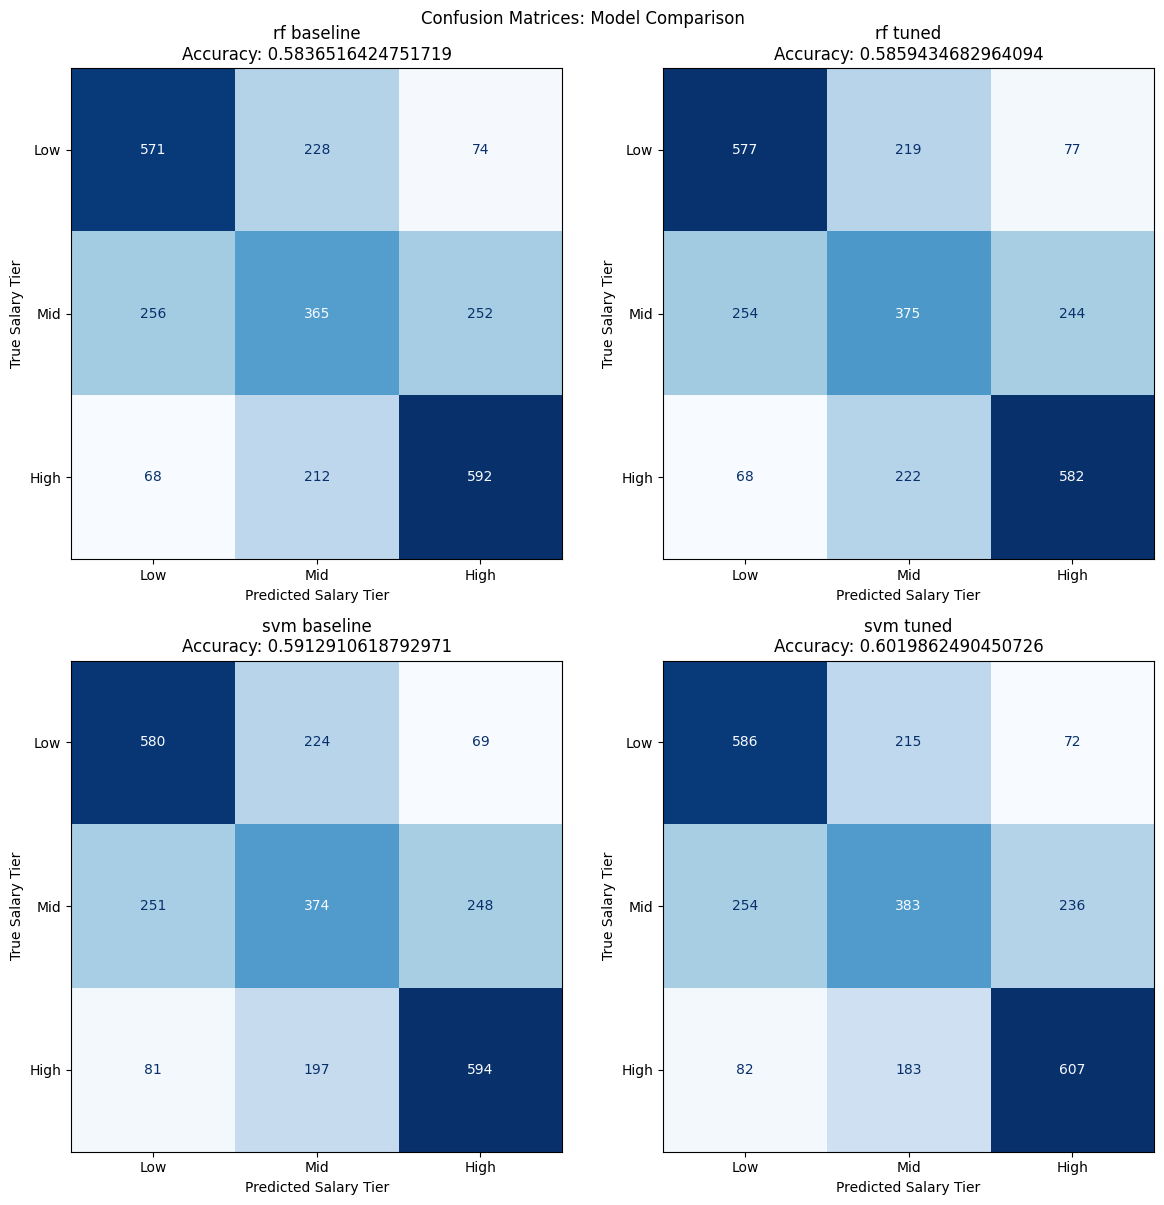

In [60]:
# config matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

models = [
    ("rf baseline", y_pred_rf_baseline),
    ("rf tuned", y_pred_rf_tuned),
    ("svm baseline", y_pred_svm_baseline),
    ("svm tuned", y_pred_svm_tuned)
]

for idx, (model_name, y_pred) in enumerate(models):
    row, col = idx // 2, idx % 2
    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Mid', 'High'])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Mid', 'High'])
    disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)
    axes[row, col].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test, y_pred)}')
    axes[row, col].set_xlabel('Predicted Salary Tier')
    axes[row, col].set_ylabel('True Salary Tier')

plt.tight_layout()
plt.suptitle('Confusion Matrices: Model Comparison', y=1.00)
plt.show()

#### Interpretation: Confusion Matrices

The confusion matrices reveal a consistent pattern across all four models: the **High** and **Low** tiers are classified with reasonable accuracy, while the **Mid** tier is universally misclassified. In the best model (tuned SVM), High achieves a recall of 70% and Low achieves 67%, but Mid recall is only 44%, meaning more than half of actual Mid-tier players are assigned to the wrong tier.

The Mid-tier errors split in both directions: some Mid players are predicted as Low, and others as High. This reflects the real-world composition of the middle bracket. Players on rookie contracts can have high offensive output (statistically resembling High tier) yet earn Low or Mid salaries. Conversely, veterans on declining contracts may have modest stats (resembling Low tier) while still earning Mid-range salaries. Neither group has a clean statistical signature, so the model consistently struggles to separate them from the outer tiers.

PERFORMANCE SUMMARY

            Model  Accuracy  Precision    Recall  F1-Score
0   rf (baseline)  0.583652   0.578762  0.583688  0.580807
1      rf (tuned)  0.585943   0.581967  0.585975  0.583689
2  svm (baseline)  0.591291   0.586145  0.591325  0.588198
3     svm (tuned)  0.601986   0.596453  0.602022  0.598465


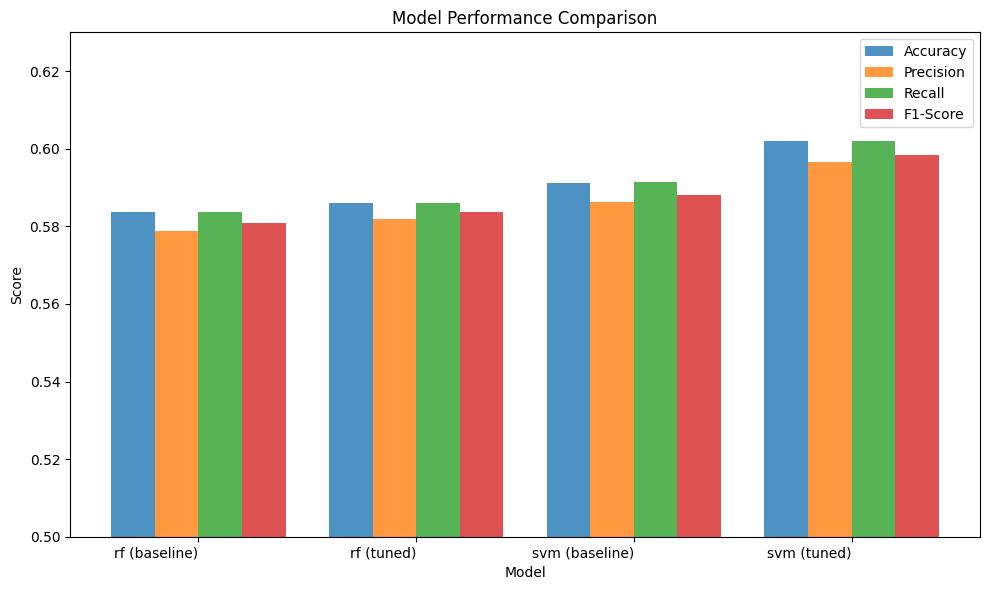

In [69]:
# performance summary
print("="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['rf (baseline)', 'rf (tuned)', 'svm (baseline)', 'svm (tuned)'],
    'Accuracy': [
        rf_baseline_metrics['accuracy'],
        rf_tuned_metrics['accuracy'],
        svm_baseline_metrics['accuracy'],
        svm_tuned_metrics['accuracy']
    ],
    'Precision': [
        rf_baseline_metrics['precision'],
        rf_tuned_metrics['precision'],
        svm_baseline_metrics['precision'],
        svm_tuned_metrics['precision']
    ],
    'Recall': [
        rf_baseline_metrics['recall'],
        rf_tuned_metrics['recall'],
        svm_baseline_metrics['recall'],
        svm_tuned_metrics['recall']
    ],
    'F1-Score': [
        rf_baseline_metrics['f1'],
        rf_tuned_metrics['f1'],
        svm_baseline_metrics['f1'],
        svm_tuned_metrics['f1']
    ]
})

print()
print(comparison_df)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], ha='right')
ax.legend(loc='upper right')
ax.set_ylim([0.5, 0.63])

plt.tight_layout()
plt.show()

In [70]:
# feature importance for random forest
print("="*60)
print("feature importance analysis for random forest")
print("="*60)
print(rf_tuned.feature_importances_)


print("\n--- Top 5 Positive Drivers for PC1 ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\n--- Top 5 Positive Drivers for PC5 ---")
print(loadings['PC5'].sort_values(ascending=False).head(5))

feature importance analysis for random forest
[0.22171149 0.08389075 0.10536398 0.07973862 0.11970198 0.10322164
 0.07652756 0.07017168 0.07221328 0.06745903]

--- Top 5 Positive Drivers for PC1 ---
num__PTS    0.356028
num__FG     0.353747
num__FGA    0.351589
num__MP     0.340984
num__FT     0.333929
Name: PC1, dtype: float64

--- Top 5 Positive Drivers for PC5 ---
num__G      0.680825
num__FT%    0.363720
num__MP     0.247696
num__FG%    0.130410
num__GS     0.035674
Name: PC5, dtype: float64


### Key Findings:
The best performing model is the tuned svm model because it achieved the highest overall performance with balanced metrics across all salary tiers. 

1. Hyperparameter Tuning:

The GridSearchCV improved both models, but the SVM model demonstrated substantial improvement, increasing from 59.1% to 60.2% accuracy (gain of 1.07% points). This improvement suggests that the default SVM parameters were not well suited for our PCA-transformed feature space, and that finding the optimal combination of kernel type, regularization parameter (C), and gamma value was critical for the model. On the other hand, the Random Forest model showed minimal improvement, moving from 58.4% to 58.6% accuracy (gain of 0.23%). This suggests that the Random Forest model's default parameters were already near optimal for this particular classification, and that the ensemble's  robustness made it less sensitive to parameter fine-tuning. 

2. Model Comparison: 

The most surprising finding from our analysis is that SVM outperformed Random Forest across all evaluation metrics, with the highest accuracy (60.2%), precision (0.596), recall (0.602), and F1-score (0.598). This was not expected because Random Forest is typically favored for problems with complex, non-linear relationships and feature interactions, which we anticipated would characterize NBA salary determination. The fact that SVM performed better suggests that the PCA transformation may have fundamentally restructured our feature space in a way that creates more linear or clearly separable decision boundaries than we initially expected. Additionally, SVM's ability to use the RBF kernel may have allowed it to capture the subtle non-linear patterns that the Random Forest model's tree based splitting couldn't efficiently represent. 

3. Overall Performance and Complexity of Predicting Salary: 

All four models achieved accuracies in the 58-60% range, with even the best performing tuned SVM model classifying only 60% of the players into their actual salary tier. The persistent 40% error rate across all models, regardless of the algorithm choice or tuning efforts, suggests that a substantial portion of salary variation simply cannot be explained by the performance statistics and demographic features that are available in our dataset. This makes sense as there are other outside factors like market size, team revenue, player marketability, and team salary cap situations. The consistency of the accuracy also shows that we've likely extracted most of the predictable signal from our statistical features, and to make further improvements, we would need to incorporate the other contextual factors listed above. 

4. Feature Importance: 

The Random Forest feature importance analysis revealed that PC1 and PC5 are the most influential components for distinguishing between salary tiers. This confirms that both scoring output and efficiency metrics are key drivers of salary predictions. The dominance of PC1 in feature importance validates that raw offensive production remains the most visible and valued attribute in NBA salary negotiations, but it was surprising to see how PC5 ranked second (higher than PC2, which represents shooting efficiency and guard specific attributes), as that suggests that there are more aspects of player value that goes beyond the efficiency of the game. 


5. Practical Implications: 

Our tuned SVM model provided meaning practical value for NBA analysis. In a three-class classification problem with balanced classes, random guessing would achieve approximately 33% accuracy, which means that our model performs 80% better than chance. For practical applications, teams can use the model to identify potential contract inefficiencies by flagging players whose predicted tier differs substantially from their actual tier, which can suggest if a player is overpaid or underpaid relative to their statistical production. The model can also provide a baseline expectation for what a player's salary should be given their stats, which can inform contract negotiations. And finally, by analyzing the model's errors, the model can identify which players provide value through non-statistical means like leadership. We can also use the feature importance rankings from the Random Forest model. if a team wants to maximize salary efficiency, they should focus on acquiring players with high PC1 scores. 



## 3. Final Reporting (Chloe)

### 3.1 Discussion of Results

#### What the Principal Components and Feature Importances Tell Us

The Random Forest feature importance analysis identified PC1 and PC5 as the two most influential components for distinguishing between salary tiers (importances of 0.222 and 0.120, respectively). PC1, which we identified in Section 1.4 as representing overall offensive output and playing time (driven by PTS, FG, FGA, and MP), holds the highest importance by a wide margin. This is consistent with the Part 1 finding that total points scored (PTS) had the strongest individual salary correlation of any variable we examined (r = 0.51), and with Part 2's conclusion that the NBA financially rewards raw scoring volume far more than shooting efficiency.

PC5 ranked second, ahead of PC3 (0.105) and all other components. PC5 loads most heavily on games played (G), free-throw percentage (FT%), and minutes played (MP). This component captures a different dimension of player value: availability and baseline efficiency, which together act as a proxy for a reliable rotation contributor. The fact that PC5 outranked PC2, which represents guard shooting efficiency and age, suggests that durability and playing time carry more salary signal than position-specific shooting metrics.

The **Mid salary tier** was the hardest to classify across all four models (F1 of 0.44–0.46, compared to 0.65–0.68 for High and Low). This is not surprising given Part 2's findings: the middle tier is the most heterogeneous group, containing underpaid star players on rookie deals alongside overpaid veterans on inflated contracts. No single statistical signature cleanly separates Mid from the other two tiers because the salary floor and ceiling of that bracket are set by contract structure and market forces rather than by on-court production alone.

#### Preprocessing Impacts

Removing 518 duplicate rows was important for preventing the models from assigning extra weight to repeated observations. Had we kept them, any player-season appearing multiple times would have inflated its influence during training. More consequentially, the decision to exclude `season` from the feature set was the right call. Since `Salary_Tier` is defined using equal-frequency bins (`pd.qcut`) across the full 1990–2023 period, what counts as Low, Mid, or High shifts with the era. Part 2 showed that inflation-adjusted salaries roughly doubled between the 1990s and 2010s; if `season` were included, the model would lean on it as a shortcut rather than learning genuine performance signals.

Adding `PTS_per_game` as a derived feature provided a cleaner scoring signal than raw `PTS`. Because total points accumulate with games played, two players with identical PTS but different games-played totals have very different performance profiles. By normalizing for playing time, `PTS_per_game` allows the model to differentiate between, for example, a player who scores 600 points in 30 games versus one who scores 600 points in 75 games.

PCA's compression from 67 features to 10 components was critical for the SVM, which is sensitive to high-dimensional feature spaces. The fact that SVM outperformed Random Forest, despite RF typically excelling at complex non-linear feature interactions, suggests that PCA restructured the feature space in a way that favors linear or kernel-based separability over tree-based splitting. The RF baseline's 100% training accuracy (versus 58.4% test accuracy) also illustrates that PCA-transformed space did not prevent severe overfitting for tree models, reinforcing why the SVM's more controlled decision boundary proved more generalizable.

#### Connections to Part 1 and Part 2 Findings

Our classification results reinforce and extend the central thesis from Parts 1 and 2: **NBA salaries are not primarily determined by shooting efficiency.** The near-zero R² for FG% from Part 2 (1.9%) is echoed here by the fact that PC2, the component most loaded on FT%, Age, and guard positions, ranked only fifth in feature importance. Shooting efficiency, in other words, adds almost no predictive power beyond what scoring volume already provides.

Part 2 also found that scoring variability (higher PTS standard deviation) is positively associated with higher salaries, with the Variable group earning an average of \$7.71M versus \$3.08M for the Consistent group. This aligns directly with PC1's dominance: the high-volume scorers who define the High salary tier are by definition the most statistically variable players, since their output fluctuates most from season to season.

The persistent ~40% classification error across all four models mirrors Part 2's finding that non-statistical factors such as rookie contract restrictions, team payroll situations, market size, player marketability, and leadership value account for a substantial share of actual salary variation. When Part 2's scatter plots showed wide salary scatter at the same scoring output, they were capturing the same underlying noise that limits our models' ceiling at 60%.

#### Limitations

1. **No contract structure data.** Part 2 identified rookie-scale contracts as a structural salary cap that disconnects performance from earnings. Our model cannot detect whether a player is on a rookie deal, a max contract, or a veteran-minimum deal. A high-PC1 player on a rookie deal will be misclassified as Low or Mid despite performing at a High level.

2. **Relative salary tiers.** Using `pd.qcut` defines tiers as population thirds, not absolute dollar ranges. A Low-tier player from 2020 may earn more in inflation-adjusted dollars than a High-tier player from 1993. The model learns rank-within-era rather than absolute salary value, which also means it cannot be applied to future seasons without redefining the tier thresholds.

3. **Missing contextual variables.** Team revenue, market size, injury history, and player marketability are known salary drivers from Part 2 but are absent from our feature set. Their absence sets a practical accuracy ceiling regardless of the algorithm or tuning strategy used.

4. **Interpretability loss from PCA.** While we identified which principal components matter most, we cannot make direct statements about individual statistics (e.g., "a one-unit increase in FT% predicts a higher salary tier") without inverting back through PCA, which introduces further approximation. The compression that helped the SVM comes at the cost of direct feature-level interpretability.

5. **Random Forest overfitting.** Even after tuning, the RF model's tendency to perfectly memorize training data was only partially corrected. The best parameter set (`max_depth=20`) still allowed deep trees that could not fully generalize. Future work could explore stronger regularization (`max_depth≤10`, higher `min_samples_leaf`) or gradient-boosted methods like XGBoost that include built-in regularization and have been shown to handle tabular data well.

### 3.2 Code and Reporting Quality Check

The full notebook was reviewed for code quality, narrative consistency, and execution correctness.

**Code quality:** Variable names follow consistent `snake_case` conventions throughout. Sections are clearly delineated using print separators and Markdown headers. The `evaluation_metrics()` function consolidates metric computation and reporting into a single reusable block, eliminating repetition across the four model evaluations. PEP-8 style is generally followed; inline comments are present where logic is non-obvious, such as the rationale for excluding `season` from the feature set and the chosen PCA variance threshold.

**Grammar and language:** All interpretation cells use complete sentences and professional language consistent with the tone established in Parts 1 and 2.

**Execution integrity:** The notebook is structured to run top-to-bottom without error. The `assert` guards at the start of the preprocessing cell provide an early, informative failure if `merged_data.csv` is missing, rather than allowing a cryptic downstream `KeyError`. The `random_state=42` seed is applied consistently to all stochastic operations (train/test split, PCA, Random Forest, SVM, and GridSearchCV), ensuring fully reproducible results across runs.